In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor

## 1 Найти и подготовить данные для задачи классификации или регрессии:

* Найдите набор данных для решения задачи классификации или регрессии.
* Подготовьте данные для анализа: проверьте их на наличие пропусков, выбросов и при необходимости произведите очистку данных.

In [ ]:
happy_data = pd.read_csv("/content/drive/MyDrive/Data/World Happiness Report 2024.csv")
happy_data

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Afghanistan,2008,3.723590,7.350416,0.450662,50.500000,0.718114,0.164055,0.881686,0.414297,0.258195
1,Afghanistan,2009,4.401778,7.508646,0.552308,50.799999,0.678896,0.187297,0.850035,0.481421,0.237092
2,Afghanistan,2010,4.758381,7.613900,0.539075,51.099998,0.600127,0.117861,0.706766,0.516907,0.275324
3,Afghanistan,2011,3.831719,7.581259,0.521104,51.400002,0.495901,0.160098,0.731109,0.479835,0.267175
4,Afghanistan,2012,3.782938,7.660506,0.520637,51.700001,0.530935,0.234157,0.775620,0.613513,0.267919
...,...,...,...,...,...,...,...,...,...,...,...
2358,Zimbabwe,2019,2.693523,7.697755,0.759162,53.099998,0.631908,-0.050874,0.830652,0.658434,0.235354
2359,Zimbabwe,2020,3.159802,7.596050,0.717243,53.575001,0.643303,0.002848,0.788523,0.660658,0.345736
2360,Zimbabwe,2021,3.154578,7.656878,0.685151,54.049999,0.667636,-0.079007,0.756945,0.609917,0.241682
2361,Zimbabwe,2022,3.296220,7.670073,0.666172,54.525002,0.651987,-0.072935,0.752632,0.640609,0.191350


In [ ]:
# Проверим на пропуски
display(happy_data.isna().sum())

,0
Country name,0
year,0
Life Ladder,0
Log GDP per capita,28
Social support,13
Healthy life expectancy at birth,63
Freedom to make life choices,36
Generosity,81
Perceptions of corruption,125
Positive affect,24


In [ ]:
# Удалим пропуски
print(f"Кол-во строк до: {happy_data.shape[0]}")
happy_data.dropna(inplace=True)
print(f"Кол-во строк после: {happy_data.shape[0]}")

Кол-во строк до: 2363
Кол-во строк после: 2097


array([[<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'Life Ladder'}>,
        <Axes: title={'center': 'Log GDP per capita'}>],
       [<Axes: title={'center': 'Social support'}>,
        <Axes: title={'center': 'Healthy life expectancy at birth'}>,
        <Axes: title={'center': 'Freedom to make life choices'}>],
       [<Axes: title={'center': 'Generosity'}>,
        <Axes: title={'center': 'Perceptions of corruption'}>,
        <Axes: title={'center': 'Positive affect'}>],
       [<Axes: title={'center': 'Negative affect'}>, <Axes: >, <Axes: >]],
      dtype=object)

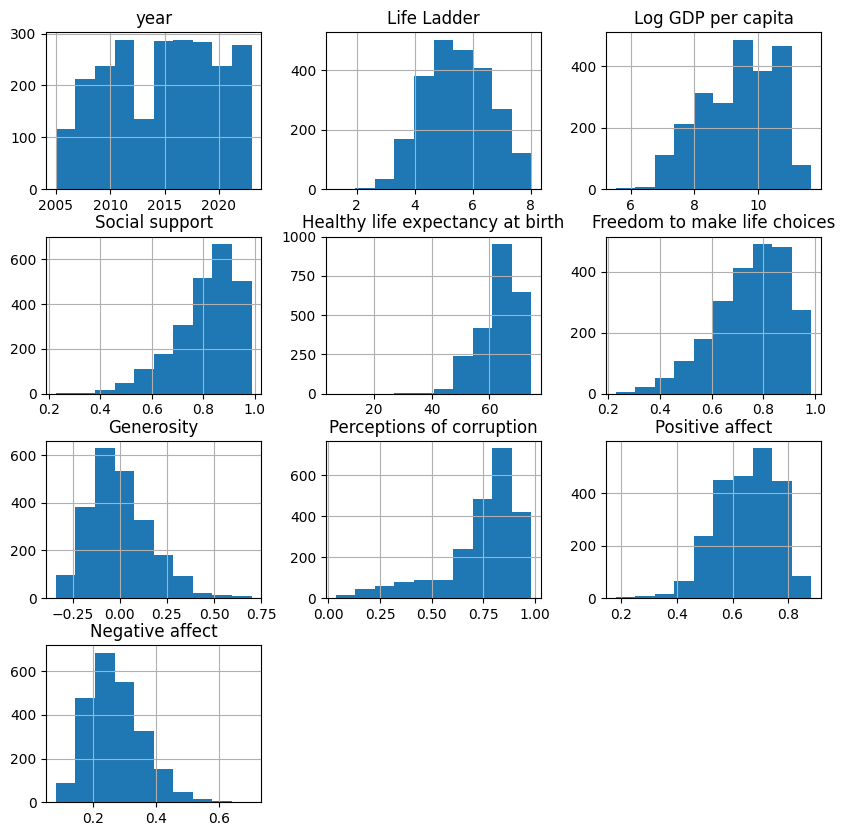

In [ ]:
# Посмотрим на распределение столбцов
happy_data.hist(figsize=(10, 10))

In [ ]:
# Масштаб разный, нужно нормализировать
X = happy_data.drop(columns=["Country name", "year", "Positive affect", 	"Negative affect"])
y = happy_data["Positive affect"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2 Построить дерево решений:

* Реализуйте дерево решений для задачи классификации или регрессии с использованием библиотеки scikit-learn.
* Проведите обучение модели на ваших данных.

In [ ]:
tree_reg = DecisionTreeRegressor(max_depth=6)
tree_reg.fit(X_train_scaled, y_train)
print(f"R^2 до подбора гиперпараметров: {tree_reg.score(X_test_scaled, y_test)}")

R^2 до подбора гиперпараметров: 0.40320730565829666


## 3 Подобрать гиперпараметры дерева решений:

* С помощью GridSearchCV выполните подбор оптимальных гиперпараметров для дерева решений (например, глубина дерева, минимальное количество образцов для разделения узла и т.д.).
* Оцените качество полученной модели с подобранными параметрами с использованием метрик, таких как точность, F1-score, RMSE или R^2 (в зависимости от задачи).

In [ ]:
tree = DecisionTreeRegressor()
# Определение сетки гиперпараметров
param_grid = {
'max_depth': list(range(3, 9)),
'min_samples_leaf': list(range(1, 20)),
'criterion': ["squared_error", "absolute_error"]
}
# Настройка GridSearchCV
grid_search = GridSearchCV(estimator=tree, param_grid=param_grid, cv=5, scoring='r2')
# Обучение и подбор гиперпараметров
grid_search.fit(X_train_scaled, y_train)
# Лучшие гиперпараметры
print("Лучшие параметры:", grid_search.best_params_)
print("Лучшие значение метрики: ", grid_search.best_score_)
# Оценка модели с лучшими параметрами
best_model = grid_search.best_estimator_
r2_tree = best_model.score(X_test_scaled, y_test)
print("R^2 после подбора гиперпарметров:", r2_tree)

Лучшие параметры: {'criterion': 'squared_error', 'max_depth': 8, 'min_samples_leaf': 15}
Лучшие значение метрики:  0.4565164475063613
R^2 после подбора гиперпарметров: 0.4420466032310838


## 4 Реализовать ансамбли моделей

* Реализуйте следующие ансамбли моделей:
1. Бэггинг (bagging)
2. Бустинг (например, с помощью XGBoost, CatBoost или LightGBM)
3. Стекинг (stacking)
* Обучите ансамбли на тех же данных и сравните их с результатами дерева решений.

In [ ]:
# Случайный лес
rf = RandomForestRegressor(n_estimators=100, max_depth=6)
rf.fit(X_train_scaled, y_train)
r2_rf = rf.score(X_test_scaled, y_test)
print(f"R^2 Random Forest: {r2_rf}")

R^2 Random Forest: 0.5339193230867045


In [ ]:
# Градиентный бустинг
gb = GradientBoostingRegressor(n_estimators=100, max_depth=3)
gb.fit(X_train_scaled, y_train)
r2_gb = gb.score(X_test_scaled, y_test)
print(f"R^2 Gradient Boosting: {r2_gb}")

R^2 Gradient Boosting: 0.55293187087833


In [ ]:
# Стэкинг
base_estimators = [
('rf', RandomForestRegressor(n_estimators=100, max_depth=6)),
('gb', GradientBoostingRegressor(n_estimators=100, max_depth=3))
]
# Метамодель
final_estimator = Ridge()
# Создание стекинг-регрессора
stacking_clf = StackingRegressor(estimators=base_estimators, final_estimator=final_estimator)
# Обучение и оценка модели
stacking_clf.fit(X_train_scaled, y_train)
r2_stack = stacking_clf.score(X_test_scaled, y_test)
print(f"R^2 Stacking: {r2_stack}")

R^2 Stacking: 0.5484160964063653


## 5 Оценить качество моделей

* Оцените качество ансамблей моделей с использованием
метрик, аналогичных тем, что использовались для дерева решений.
* Сравните производительность различных ансамблей с базовой моделью дерева решений и сделайте выводы, какая модель лучше решает задачу.

In [ ]:
pd.DataFrame({"Model": ["Decision Tree", "Random Forest", "Gradient Boosting", "Stacking"],
              "R^2": [r2_tree, r2_rf, r2_gb, r2_stack]})

,Model,R^2
0,Decision Tree,0.442047
1,Random Forest,0.533919
2,Gradient Boosting,0.552932
3,Stacking,0.548416
